
# The AI Confidence Trap
## La IA no es el problema. La dependencia pasiva sí.

Este notebook está diseñado para una entrega de **data storytelling**. La intención no es hacer un modelo complejo, sino construir una historia clara con visualizaciones simples.

**Big Idea**  
En este dataset sintético, el uso intensivo de IA no parece ser el problema por sí solo. La diferencia aparece cuando comparamos a estudiantes que usan IA y siguen construyendo habilidades propias frente a estudiantes que usan IA intensivamente pero muestran bajo aprendizaje autónomo, menor claridad profesional y mayor ansiedad.

**Audiencia:** servicios de carrera, profesores, coordinadores académicos y equipos de éxito estudiantil.  
**Acción esperada:** enseñar a usar IA como herramienta para construir habilidades, no como reemplazo del pensamiento propio.

> Nota importante: el dataset es sintético. El análisis es exploratorio y no establece causalidad.



## 1. Setup y carga de datos

Cargamos el dataset, revisamos su estructura y aplicamos una limpieza mínima para poder graficar sin errores.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

# Use only the real dataset stored in this project folder.
PROJECT_DIR = Path(r"C:\Users\david\DataVizProject")
DATA_PATH = PROJECT_DIR / "ai_dependency_career_anxiety_students.csv"
FIG_DIR = PROJECT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)


if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

# Load data from the local project folder only.
df = pd.read_csv(DATA_PATH)

# The local CSV has padded column names and a leading "<<" in the first header.
# Normalize those labels so the rest of the notebook can use the intended variable names.
df.columns = [col.strip().lstrip("<").strip() for col in df.columns]

# Normalize text values and recover numeric columns from the padded CSV format.
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip()

# Convert columns that are actually numeric but were read as text because of spacing.
for col in df.columns:
    if col == "student_id":
        continue
    numeric_version = pd.to_numeric(df[col], errors="coerce")
    if numeric_version.notna().mean() >= 0.95:
        df[col] = numeric_version

# Basic cleaning: fill numeric missing values with median and categorical missing values with "Not reported"
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna("Not reported")

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print("Missing values after cleaning:", int(df.isna().sum().sum()))
df.head()

C:\Users\david\AppData\Local\Temp\ipykernel_28080\3822426670.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


Dataset loaded from: C:\Users\david\DataVizProject\ai_dependency_career_anxiety_students.csv
Rows: 15,000
Columns: 30
Missing values after cleaning: 0


C:\Users\david\AppData\Local\Temp\ipykernel_28080\3822426670.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64



## 2. Variables que usaremos en la historia

No vamos a usar todas las columnas. Para que la historia sea clara, nos enfocamos en tres bloques:

1. **Uso de IA:** `daily_ai_tool_usage_hrs`, `ai_dependency_score`, `ai_replaces_own_thinking_score`.
2. **Respuesta emocional/profesional:** `fear_of_job_loss_to_ai`, `placement_anxiety_score`, `burnout_score`, `motivation_score`.
3. **Construcción de habilidades:** `self_learning_hours_per_week`, `skill_development_courses_taken`, `internship_experience`, `career_clarity_score`, `overall_career_readiness_score`.


In [7]:

story_vars = [
    "daily_ai_tool_usage_hrs", "ai_dependency_score", "ai_replaces_own_thinking_score",
    "fear_of_job_loss_to_ai", "placement_anxiety_score", "burnout_score", "motivation_score",
    "self_learning_hours_per_week", "skill_development_courses_taken", "internship_experience",
    "career_clarity_score", "overall_career_readiness_score", "resume_confidence_score"
]

df[story_vars].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
daily_ai_tool_usage_hrs,15000.0,2.01,1.74,0.0,0.4,1.8,3.20,8.0
ai_dependency_score,15000.0,4.54,2.32,1.0,3.0,4.0,6.00,10.0
ai_replaces_own_thinking_score,15000.0,2.99,1.31,1.0,2.0,3.0,4.00,5.0
fear_of_job_loss_to_ai,15000.0,3.55,1.18,1.0,3.0,4.0,5.00,5.0
placement_anxiety_score,15000.0,5.91,2.55,1.0,4.0,6.0,8.00,10.0
burnout_score,15000.0,5.47,2.07,1.0,4.0,5.0,7.00,10.0
motivation_score,15000.0,4.32,2.15,1.0,3.0,4.0,6.00,10.0
self_learning_hours_per_week,15000.0,6.29,5.51,0.0,1.1,5.5,10.00,31.0
skill_development_courses_taken,15000.0,2.03,1.81,0.0,1.0,2.0,3.00,10.0
internship_experience,15000.0,1.72,1.07,0.0,1.0,2.0,2.00,4.0



## 3. Contexto inicial
### AI is already part of student life

Primero abrimos con un dato simple: el promedio de horas diarias de uso de IA en el dataset.

Este visual funciona como una **slide de contexto**, no como una gráfica técnica.


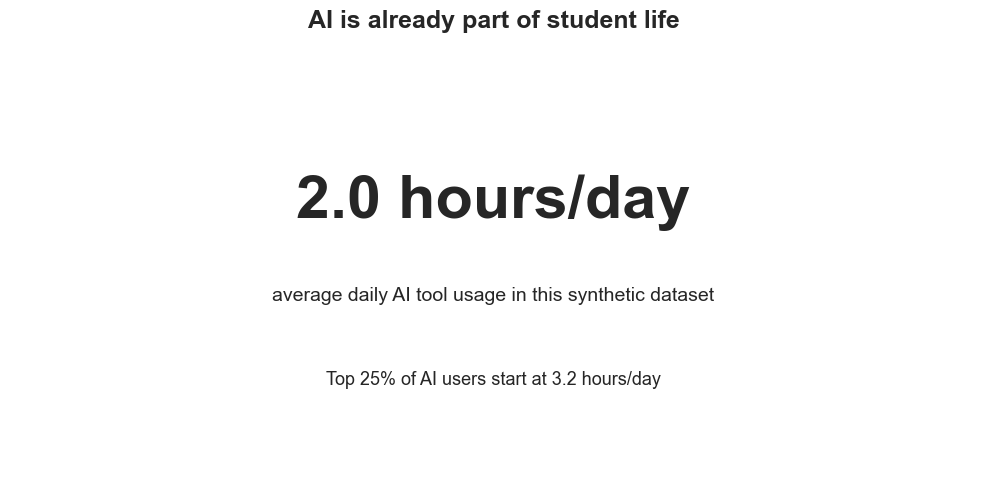

In [8]:

avg_ai_hours = df["daily_ai_tool_usage_hrs"].mean()
high_ai_cutoff = df["daily_ai_tool_usage_hrs"].quantile(0.75)
high_ai_share = (df["daily_ai_tool_usage_hrs"] >= high_ai_cutoff).mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")
ax.text(0.5, 0.65, f"{avg_ai_hours:.1f} hours/day", ha="center", va="center", fontsize=44, fontweight="bold")
ax.text(0.5, 0.43, "average daily AI tool usage in this synthetic dataset", ha="center", va="center", fontsize=14)
ax.text(0.5, 0.23, f"Top 25% of AI users start at {high_ai_cutoff:.1f} hours/day", ha="center", va="center", fontsize=13)
ax.set_title("AI is already part of student life", fontsize=18, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_kpi_ai_usage.png", dpi=200, bbox_inches="tight")
plt.show()



## 4. El uso de IA cambia según el área académica
### AI use is not evenly distributed across streams

Antes de comparar ansiedad o preparación, conviene mostrar que el uso de IA no es igual en todas las áreas de estudio. Usamos un **lollipop chart** porque se lee como ranking, pero es menos pesado que barras largas.


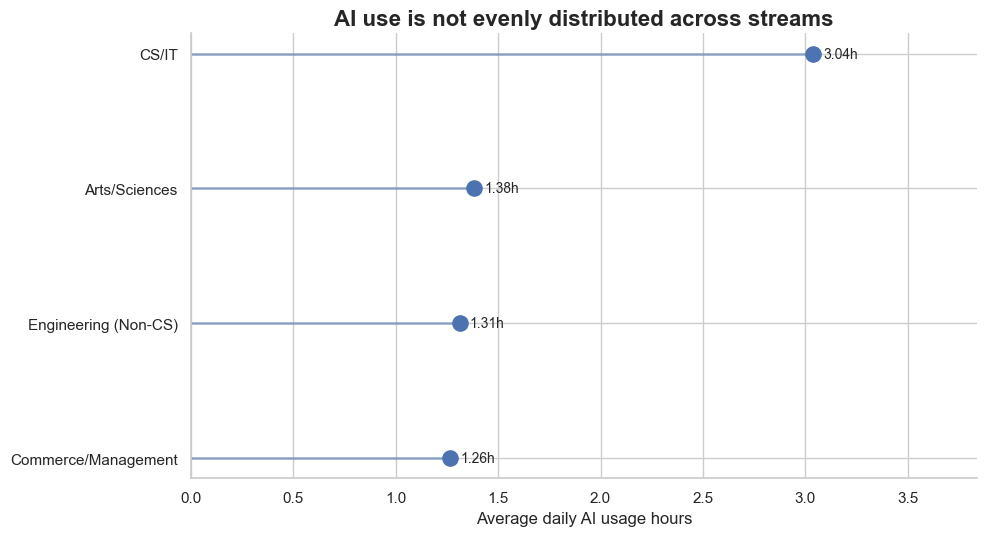

,stream,daily_ai_tool_usage_hrs
2,Commerce/Management,1.26
3,Engineering (Non-CS),1.31
0,Arts/Sciences,1.38
1,CS/IT,3.04


In [9]:

stream_usage = (
    df.groupby("stream", as_index=False)["daily_ai_tool_usage_hrs"]
      .mean()
      .sort_values("daily_ai_tool_usage_hrs")
)

fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(stream_usage))
ax.hlines(y=y, xmin=0, xmax=stream_usage["daily_ai_tool_usage_hrs"], linewidth=2, alpha=0.5)
ax.scatter(stream_usage["daily_ai_tool_usage_hrs"], y, s=120)

for i, val in enumerate(stream_usage["daily_ai_tool_usage_hrs"]):
    ax.text(val + 0.05, i, f"{val:.2f}h", va="center", fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(stream_usage["stream"])
ax.set_xlabel("Average daily AI usage hours")
ax.set_title("AI use is not evenly distributed across streams", fontsize=16, fontweight="bold")
ax.set_xlim(0, stream_usage["daily_ai_tool_usage_hrs"].max() + 0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_lollipop_stream_ai_usage.png", dpi=200, bbox_inches="tight")
plt.show()

stream_usage.round(2)



## 5. Comparación 1: uso intensivo de IA con o sin aprendizaje autónomo
### High AI use looks different when students also learn outside class

Aquí está el primer insight importante: no basta con saber si el estudiante usa mucha IA. Queremos saber si también está construyendo habilidades propias.

Para hacerlo simple, comparamos dos grupos dentro de los estudiantes con **alto uso de IA**:

- **High AI + low self-learning:** estudiantes con alto uso de IA y bajo aprendizaje autónomo.
- **High AI + high self-learning:** estudiantes con alto uso de IA y alto aprendizaje autónomo.

Estos grupos son solo para comparación visual, no son perfiles definitivos ni diagnósticos.


In [10]:

# Cutoffs used only to create clear comparison groups
high_ai_cutoff = df["daily_ai_tool_usage_hrs"].quantile(0.75)
low_self_cutoff = df["self_learning_hours_per_week"].quantile(0.25)
high_self_cutoff = df["self_learning_hours_per_week"].quantile(0.75)

high_ai = df[df["daily_ai_tool_usage_hrs"] >= high_ai_cutoff].copy()

ai_low_self = high_ai[high_ai["self_learning_hours_per_week"] <= low_self_cutoff]
ai_high_self = high_ai[high_ai["self_learning_hours_per_week"] >= high_self_cutoff]

print(f"High AI use cutoff: {high_ai_cutoff:.2f} hours/day")
print(f"Low self-learning cutoff: <= {low_self_cutoff:.2f} hours/week")
print(f"High self-learning cutoff: >= {high_self_cutoff:.2f} hours/week")
print(f"High AI + low self-learning students: {len(ai_low_self):,}")
print(f"High AI + high self-learning students: {len(ai_high_self):,}")


High AI use cutoff: 3.20 hours/day
Low self-learning cutoff: <= 1.10 hours/week
High self-learning cutoff: >= 10.00 hours/week
High AI + low self-learning students: 321
High AI + high self-learning students: 1,785


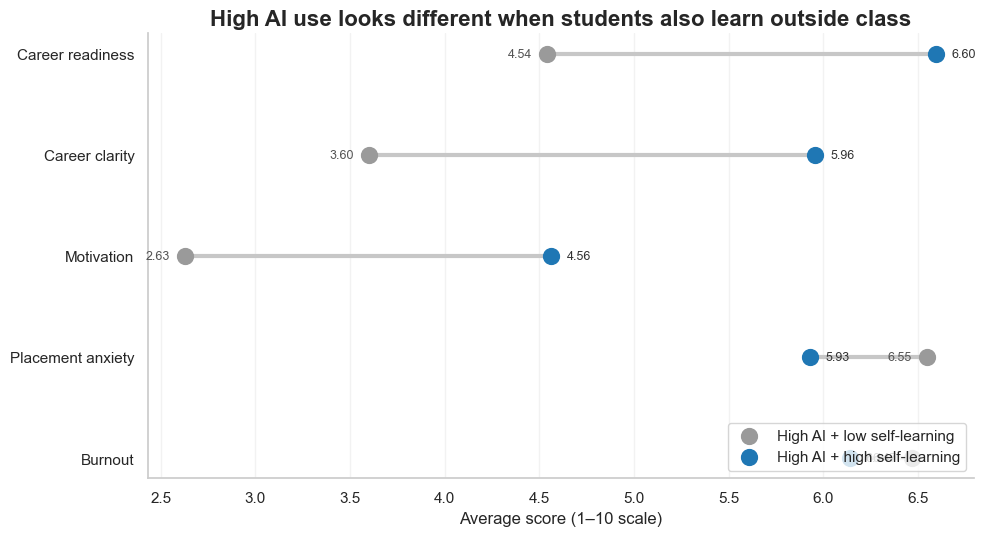

,metric,High AI + low self-learning,High AI + high self-learning,difference
0,Career readiness,4.54,6.60,2.05
1,Career clarity,3.60,5.96,2.36
2,Motivation,2.63,4.56,1.93
3,Placement anxiety,6.55,5.93,-0.62
4,Burnout,6.47,6.14,-0.32


In [11]:

def create_comparison_df(group_a, group_b, label_a, label_b, metrics, metric_labels):
    rows = []
    for metric in metrics:
        rows.append({
            "metric": metric_labels.get(metric, metric),
            label_a: group_a[metric].mean(),
            label_b: group_b[metric].mean(),
            "difference": group_b[metric].mean() - group_a[metric].mean()
        })
    return pd.DataFrame(rows)

def dumbbell_plot(comp_df, label_left, label_right, title, xlabel, filename, left_color="#9a9a9a", right_color="#1f77b4"):
    plot_df = comp_df.copy().iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 5.5))
    y = np.arange(len(plot_df))

    ax.hlines(y=y, xmin=plot_df[label_left], xmax=plot_df[label_right], color="#c7c7c7", linewidth=3, zorder=1)
    ax.scatter(plot_df[label_left], y, s=130, color=left_color, label=label_left, zorder=2)
    ax.scatter(plot_df[label_right], y, s=130, color=right_color, label=label_right, zorder=3)

    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row[label_left] - 0.08, i, f"{row[label_left]:.2f}", va="center", ha="right", fontsize=9, color="#555555")
        ax.text(row[label_right] + 0.08, i, f"{row[label_right]:.2f}", va="center", ha="left", fontsize=9, color="#333333")

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["metric"])
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.legend(loc="lower right", frameon=True)
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

metric_labels = {
    "overall_career_readiness_score": "Career readiness",
    "career_clarity_score": "Career clarity",
    "motivation_score": "Motivation",
    "placement_anxiety_score": "Placement anxiety",
    "burnout_score": "Burnout"
}

core_metrics = list(metric_labels.keys())

comp_self_learning = create_comparison_df(
    ai_low_self,
    ai_high_self,
    "High AI + low self-learning",
    "High AI + high self-learning",
    core_metrics,
    metric_labels
)

dumbbell_plot(
    comp_self_learning,
    "High AI + low self-learning",
    "High AI + high self-learning",
    "High AI use looks different when students also learn outside class",
    "Average score (1–10 scale)",
    "03_dumbbell_high_ai_self_learning.png"
)

comp_self_learning.round(2)



**Insight:** Entre los estudiantes con alto uso de IA, los que también tienen alto aprendizaje autónomo muestran mayor preparación, claridad y motivación. Esto cambia la historia: el uso intensivo de IA no se interpreta igual cuando existe construcción activa de habilidades.



## 6. Comparación 2: miedo al reemplazo laboral con acción o sin acción
### Fear can become action — or just anxiety

Esta comparación parte de estudiantes con alto miedo a perder oportunidades laborales por la IA. Luego preguntamos:

> ¿Ese miedo viene acompañado de acciones concretas para desarrollar habilidades?

Comparamos:

- **Fear + no action:** alto miedo, bajo aprendizaje autónomo y pocos cursos.
- **Fear + action:** alto miedo, alto aprendizaje autónomo y más cursos de desarrollo de habilidades.


In [12]:

high_fear_cutoff = df["fear_of_job_loss_to_ai"].quantile(0.75)
low_courses_cutoff = df["skill_development_courses_taken"].quantile(0.25)
high_courses_cutoff = df["skill_development_courses_taken"].quantile(0.75)

high_fear = df[df["fear_of_job_loss_to_ai"] >= high_fear_cutoff].copy()

fear_no_action = high_fear[
    (high_fear["self_learning_hours_per_week"] <= low_self_cutoff) &
    (high_fear["skill_development_courses_taken"] <= low_courses_cutoff)
]

fear_action = high_fear[
    (high_fear["self_learning_hours_per_week"] >= high_self_cutoff) &
    (high_fear["skill_development_courses_taken"] >= high_courses_cutoff)
]

print(f"High fear cutoff: >= {high_fear_cutoff:.0f} on a 1–5 scale")
print(f"Fear + no action students: {len(fear_no_action):,}")
print(f"Fear + action students: {len(fear_action):,}")


High fear cutoff: >= 5 on a 1–5 scale
Fear + no action students: 582
Fear + action students: 566


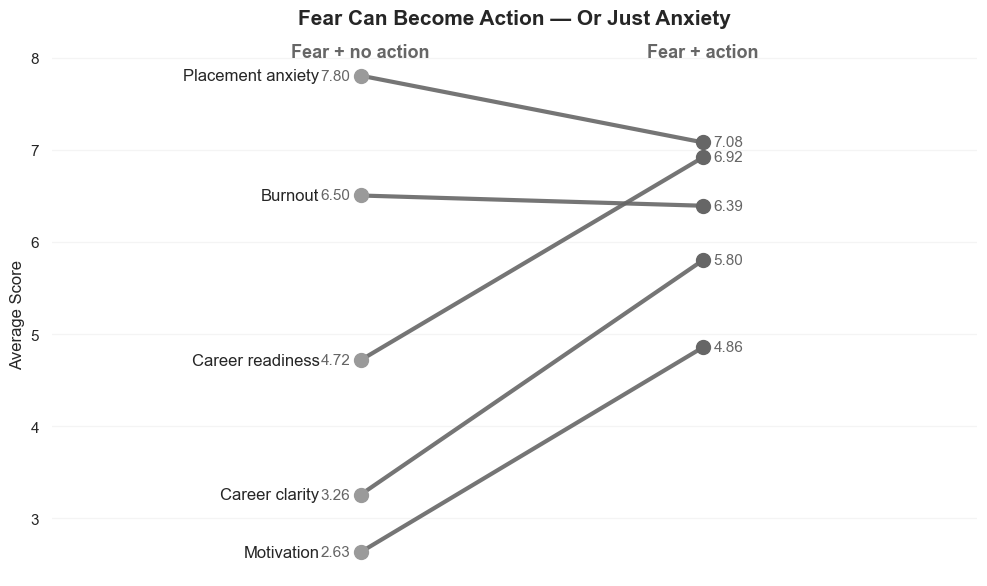

,metric,Fear + no action,Fear + action,difference
0,Career readiness,4.72,6.92,2.20
1,Career clarity,3.26,5.80,2.54
2,Motivation,2.63,4.86,2.22
3,Placement anxiety,7.80,7.08,-0.72
4,Burnout,6.50,6.39,-0.11


In [39]:

import matplotlib.pyplot as plt
import numpy as np

comp_fear_action = create_comparison_df(
    fear_no_action,
    fear_action,
    "Fear + no action",
    "Fear + action",
    core_metrics,
    metric_labels
)

plot_df = comp_fear_action.copy()

fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(plot_df))[::-1]

for i, row in plot_df.iterrows():

    left = row["Fear + no action"]
    right = row["Fear + action"]

    # Verde si mejora, rojo si empeora
    color = "#666666" if right > left else "#666666"

    # línea inclinada
    ax.plot(
        [0, 1],
        [left, right],
        color=color,
        linewidth=3,
        alpha=0.9
    )

    # puntos
    ax.scatter(0, left, s=100, color="#9a9a9a", zorder=3)
    ax.scatter(1, right, s=100, color=color, zorder=3)

    # nombre de la métrica
    ax.text(
        -0.12,
        left,
        row["metric"],
        ha="right",
        va="center",
        fontsize=12
    )

    # valor izquierda
    ax.text(
        -0.03,
        left,
        f"{left:.2f}",
        ha="right",
        va="center",
        fontsize=11,
        color="#666666"
    )

    # valor derecha
    ax.text(
        1.03,
        right,
        f"{right:.2f}",
        ha="left",
        va="center",
        fontsize=11,
        color=color
    )

# etiquetas de columnas
ax.text(
    0,
    plot_df[["Fear + no action", "Fear + action"]].max().max() + 0.2,
    "Fear + no action",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="#666666"
)

ax.text(
    1,
    plot_df[["Fear + no action", "Fear + action"]].max().max() + 0.2,
    "Fear + action",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="#666666"
)

ax.set_title(
    "Fear Can Become Action — Or Just Anxiety",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.set_xlim(-0.90, 1.80)
ax.set_xticks([])
ax.set_ylabel("Average Score")
ax.grid(axis="y", alpha=0.2)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

comp_fear_action.round(2)



**Insight:** El miedo al reemplazo laboral no necesariamente lleva a una misma respuesta. En este dataset, quienes responden con aprendizaje autónomo y cursos muestran más readiness, claridad y motivación que quienes tienen miedo pero no invierten en habilidades.



## 7. Comparación 3: alta dependencia de IA con o sin cursos de habilidades
### Skill-building changes the meaning of dependency

Ahora filtramos estudiantes con alta dependencia de IA y revisamos si los cursos de habilidades cambian la lectura.

Comparamos:

- **High dependency + few courses**
- **High dependency + more courses**


In [41]:

high_dependency_cutoff = df["ai_dependency_score"].quantile(0.75)
high_dep = df[df["ai_dependency_score"] >= high_dependency_cutoff].copy()

dep_few_courses = high_dep[high_dep["skill_development_courses_taken"] <= low_courses_cutoff]
dep_more_courses = high_dep[high_dep["skill_development_courses_taken"] >= high_courses_cutoff]

print(f"High AI dependency cutoff: >= {high_dependency_cutoff:.1f} on a 1–10 scale")
print(f"High dependency + few courses students: {len(dep_few_courses):,}")
print(f"High dependency + more courses students: {len(dep_more_courses):,}")


High AI dependency cutoff: >= 6.0 on a 1–10 scale
High dependency + few courses students: 2,449
High dependency + more courses students: 1,519


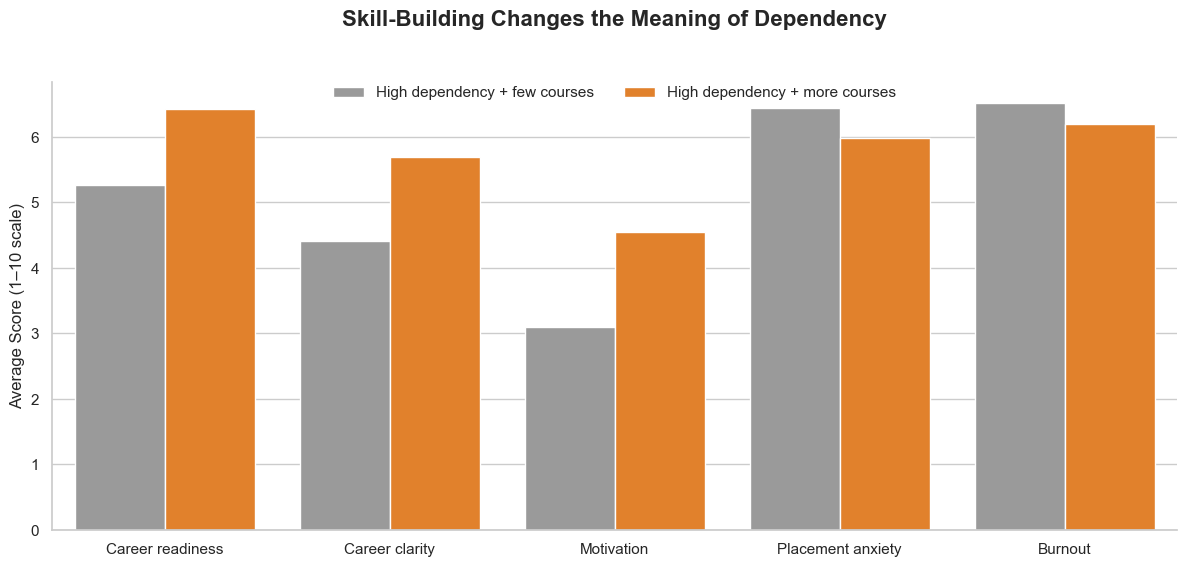

,metric,High dependency + few courses,High dependency + more courses,difference
0,Career readiness,5.27,6.43,1.16
1,Career clarity,4.41,5.70,1.29
2,Motivation,3.10,4.55,1.45
3,Placement anxiety,6.44,5.98,-0.45
4,Burnout,6.52,6.20,-0.32


In [53]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metrics_courses = [
    "overall_career_readiness_score", "career_clarity_score", "motivation_score",
    "placement_anxiety_score", "burnout_score"
]

comp_courses = create_comparison_df(
    dep_few_courses,
    dep_more_courses,
    "High dependency + few courses",
    "High dependency + more courses",
    metrics_courses,
    metric_labels
)

# Convertir a formato largo
plot_df = comp_courses.melt(
    id_vars="metric",
    value_vars=[
        "High dependency + few courses",
        "High dependency + more courses"
    ],
    var_name="Group",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="metric",
    y="Score",
    hue="Group",
    palette={
        "High dependency + few courses": "#9a9a9a",
        "High dependency + more courses": "#ff7f0e"
    }
)

sns.despine()

plt.title(
    "Skill-Building Changes the Meaning of Dependency",
    fontsize=16,
    fontweight="bold",
    pad=40
)

plt.xlabel("")
plt.ylabel("Average Score (1–10 scale)")

plt.xticks(ha="center")

plt.legend(
    title="",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.tight_layout()
plt.subplots_adjust(top=0.82)
plt.show()

comp_courses.round(2)



**Insight:** La dependencia de IA no debe leerse de forma aislada. Cuando los estudiantes con alta dependencia también toman más cursos, aparecen mejores señales de claridad, motivación y preparación profesional.



## 8. Comparación 4: uso intensivo de IA con o sin internship
### Practice still builds career readiness

Esta comparación conecta directamente con la idea de preparación profesional. Dentro de estudiantes con alto uso de IA, comparamos a quienes tienen experiencia de internship contra quienes no la tienen.


In [11]:

high_ai_no_internship = high_ai[high_ai["internship_experience"] == 0]
high_ai_with_internship = high_ai[high_ai["internship_experience"] >= 1]

print(f"High AI + no internship students: {len(high_ai_no_internship):,}")
print(f"High AI + internship students: {len(high_ai_with_internship):,}")


High AI + no internship students: 525
High AI + internship students: 3,319


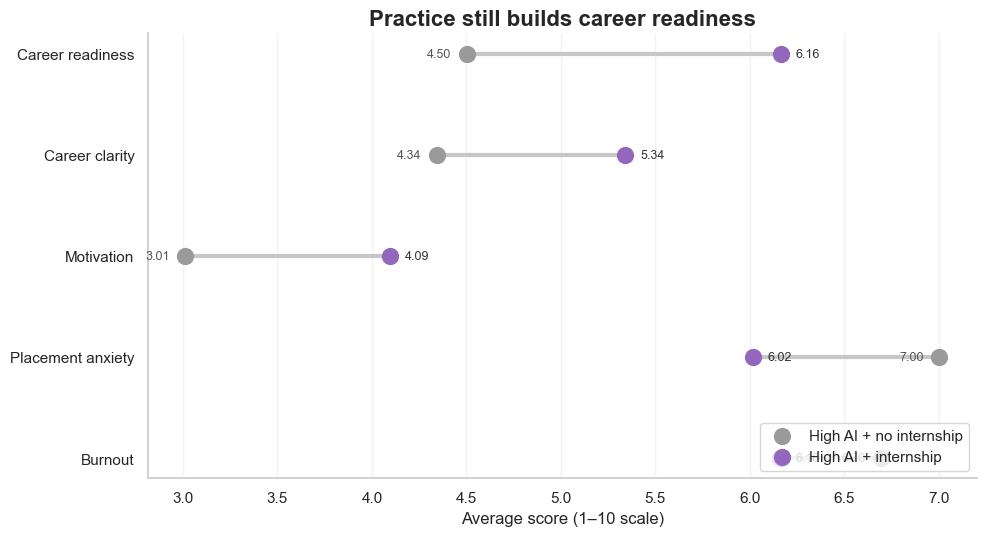

,metric,High AI + no internship,High AI + internship,difference
0,Career readiness,4.50,6.16,1.66
1,Career clarity,4.34,5.34,1.00
2,Motivation,3.01,4.09,1.08
3,Placement anxiety,7.00,6.02,-0.99
4,Burnout,6.70,6.16,-0.54


In [12]:

comp_internship = create_comparison_df(
    high_ai_no_internship,
    high_ai_with_internship,
    "High AI + no internship",
    "High AI + internship",
    core_metrics,
    metric_labels
)

dumbbell_plot(
    comp_internship,
    "High AI + no internship",
    "High AI + internship",
    "Practice still builds career readiness",
    "Average score (1–10 scale)",
    "06_dumbbell_high_ai_internship.png",
    left_color="#9a9a9a",
    right_color="#9467bd"
)

comp_internship.round(2)



**Insight:** Incluso entre estudiantes que usan IA intensivamente, la experiencia práctica cambia la lectura. La IA puede ayudar, pero la experiencia real sigue siendo una fuente importante de confianza y preparación.



## 9. Comparación 5: cuando la IA reemplaza el pensamiento propio
### The warning sign is replacement, not usage

Para cerrar la evidencia central, comparamos estudiantes con bajo y alto puntaje en `ai_replaces_own_thinking_score`.

Esta comparación va al corazón de la historia: **usar IA no es el problema; el problema aparece cuando el estudiante siente que la IA reemplaza su propio razonamiento.**


In [13]:

low_replacement_cutoff = df["ai_replaces_own_thinking_score"].quantile(0.25)
high_replacement_cutoff = df["ai_replaces_own_thinking_score"].quantile(0.75)

low_replacement = df[df["ai_replaces_own_thinking_score"] <= low_replacement_cutoff]
high_replacement = df[df["ai_replaces_own_thinking_score"] >= high_replacement_cutoff]

print(f"Low replacement cutoff: <= {low_replacement_cutoff:.0f} on a 1–5 scale")
print(f"High replacement cutoff: >= {high_replacement_cutoff:.0f} on a 1–5 scale")
print(f"Low replacement students: {len(low_replacement):,}")
print(f"High replacement students: {len(high_replacement):,}")


Low replacement cutoff: <= 2 on a 1–5 scale
High replacement cutoff: >= 4 on a 1–5 scale
Low replacement students: 5,634
High replacement students: 5,451


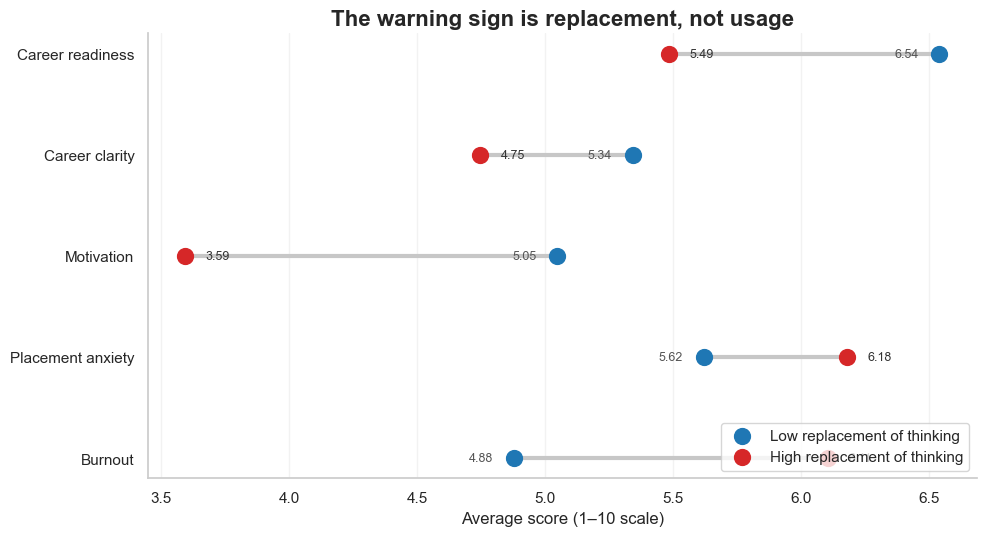

,metric,Low replacement of thinking,High replacement of thinking,difference
0,Career readiness,6.54,5.49,-1.05
1,Career clarity,5.34,4.75,-0.60
2,Motivation,5.05,3.59,-1.45
3,Placement anxiety,5.62,6.18,0.56
4,Burnout,4.88,6.11,1.23


In [14]:

comp_replacement = create_comparison_df(
    low_replacement,
    high_replacement,
    "Low replacement of thinking",
    "High replacement of thinking",
    core_metrics,
    metric_labels
)

dumbbell_plot(
    comp_replacement,
    "Low replacement of thinking",
    "High replacement of thinking",
    "The warning sign is replacement, not usage",
    "Average score (1–10 scale)",
    "07_dumbbell_replacement_thinking.png",
    left_color="#1f77b4",
    right_color="#d62728"
)

comp_replacement.round(2)



**Insight:** Cuando la IA reemplaza más el pensamiento propio, los estudiantes muestran menor readiness, menor claridad y menor motivación, mientras que ansiedad y burnout suben. Este es el argumento central de la historia.



## 10. Resumen de insights

1. **El uso de IA no debe interpretarse solo por horas.** El mismo nivel alto de uso puede verse distinto si el estudiante también desarrolla habilidades propias.
2. **El aprendizaje autónomo cambia la lectura del alto uso de IA.** Quienes usan mucha IA y también aprenden por fuera muestran mejores señales de preparación.
3. **El miedo al reemplazo puede transformarse en acción o en ansiedad.** La diferencia aparece cuando hay cursos, self-learning y desarrollo de habilidades.
4. **La experiencia práctica sigue siendo clave.** Entre estudiantes con alto uso de IA, quienes tienen internship muestran más readiness y claridad.
5. **La señal crítica es el reemplazo del pensamiento propio.** Cuando la IA sustituye el razonamiento del estudiante, aparecen peores indicadores de motivación, claridad y preparación.

**Conclusión:** La universidad no debería enfocarse en prohibir el uso de IA, sino en enseñar a usarla como herramienta de construcción de habilidades.



## 11. Storyboard para presentación

| Slide | Título accionable | Visual | Mensaje |
|---|---|---|---|
| 1 | **AI is already part of student life** | KPI / texto grande | La IA ya está presente en la rutina estudiantil. |
| 2 | **AI use is not evenly distributed across streams** | Lollipop chart | El uso de IA cambia por área académica. |
| 3 | **High AI use looks different when students also learn outside class** | Dumbbell plot | Alto uso de IA no significa lo mismo si existe aprendizaje autónomo. |
| 4 | **Fear can become action — or just anxiety** | Dumbbell plot | El miedo al reemplazo puede ir acompañado de acción o de ansiedad. |
| 5 | **Skill-building changes the meaning of dependency** | Dumbbell plot | Los cursos de habilidades modifican cómo se interpreta la dependencia. |
| 6 | **Practice still builds career readiness** | Dumbbell plot | La experiencia práctica sigue siendo clave para readiness. |
| 7 | **The warning sign is replacement, not usage** | Dumbbell plot | El verdadero riesgo aparece cuando la IA reemplaza el pensamiento propio. |
| 8 | **Universities should teach AI as a skill-building tool** | Slide de recomendación | La solución es guiar el uso de IA, no prohibirlo. |



## 12. Recomendaciones para la audiencia

- Crear talleres de **AI literacy** donde los estudiantes aprendan a usar IA como apoyo al razonamiento.
- Integrar IA con programas de **career readiness**, no tratarla como una herramienta separada.
- Promover aprendizaje autónomo, cursos de habilidades, internships y práctica de entrevistas.
- Detectar estudiantes que usan IA intensivamente pero no están desarrollando habilidades propias.
- Evitar comunicar la IA como amenaza absoluta: el problema no es usarla, sino depender de ella sin construir capacidades.



## 13. Limitaciones

- El dataset es sintético; por lo tanto, los resultados no deben interpretarse como evidencia real sobre estudiantes.
- El análisis es exploratorio y descriptivo.
- No se hacen afirmaciones causales.
- Los grupos comparados se crean solo para contar una historia visual y no representan diagnósticos.
- Para tomar decisiones institucionales reales se necesitarían datos reales de estudiantes, encuestas validadas y revisión ética.



## 14. Reflexión

El principal reto fue evitar una historia demasiado simple como “más IA = más ansiedad”. Esa lectura era fácil, pero limitada. La versión final busca una historia más útil: el uso de IA puede ser positivo si se combina con aprendizaje autónomo, cursos, internships y claridad profesional. El diseño de las visualizaciones busca comparar comportamientos, no solo mostrar líneas que suben. Esto hace que el storytelling sea más humano, más accionable y más alineado con una audiencia universitaria.


In [15]:
# Save cleaned sample for submission in the project folder.
sample_path = Path(r"C:\Users\unbue\DataVizProject\ai_confidence_trap_comparison_clean_sample.csv")
df.sample(min(5000, len(df)), random_state=42).to_csv(sample_path, index=False)
print(f"Clean sample saved to: {sample_path}")
print(f"Figures saved to: {FIG_DIR}")

Clean sample saved to: C:\Users\unbue\DataVizProject\ai_confidence_trap_comparison_clean_sample.csv
Figures saved to: C:\Users\unbue\DataVizProject\figures
